# Linguistic Analysis: Metacom Green
**Group 0 = Control · Group 1 = Training · Pre vs Post**

Analyses:
1. Length & elaboration (token count)
2. Connectives (total) and causal connectives
3. TTR – lexical variability
4. VAD – valence, arousal, dominance (pre-computed)
5. Concreteness / imageability (optional: requires Italian norms CSV)
6. Most frequent content terms by group × time
7. Sentence-embedding distance from the 5 topic prompts

In [2]:
# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

import nltk
for _res, _kind in [('punkt_tab', 'tokenizers'), ('stopwords', 'corpora')]:
    try:
        nltk.data.find(f'{_kind}/{_res}')
    except LookupError:
        nltk.download(_res, quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

COLORS   = {0: "#D998D3", 1: "#8D6ED8"}
LABELS   = {0: 'Control', 1: 'Training'}
TIME_ORD = ['pre', 'post']

print('All imports OK')

All imports OK


In [3]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
DATA_FILE = 'data/Df_metacomgreen_dominance_enriched (1).xlsx'
df = pd.read_excel(DATA_FILE)

PROMPTS = {
    1: 'Cambiamento climatico',
    2: 'Inquinamento',
    3: 'Ghiacciai',
    4: 'Mare',
    5: 'Piante',
}

print(f'Subjects: {len(df)}  |  G0={int((df["Gruppo"]==0).sum())}  G1={int((df["Gruppo"]==1).sum())}')
df[['ID', 'Gruppo']].head(3)

Subjects: 68  |  G0=33  G1=35


,ID,Gruppo
0,ISG001,0
1,ISG002,1
2,ISG003,1


In [4]:
# ── 2. RESHAPE TO LONG FORMAT ─────────────────────────────────────────────────
# Each row = one subject × time × item
# text = conceptualization_a + elaboration_b concatenated

def _safe(v):
    return str(v).strip() if pd.notna(v) and str(v).strip() not in ('', 'nan') else ''

records = []
for _, row in df.iterrows():
    for time in ('pre', 'post'):
        for item in range(1, 6):
            ca = f'Conceptualization_{time}_{item}a'
            cb = f'Conceptualization_{time}_{item}b'
            ta, tb = _safe(row.get(ca)), _safe(row.get(cb))
            text = (ta + ' ' + tb).strip()
            if not text:
                continue

            # VAD: average of sub-responses a and b
            vad = {}
            for dim in ('val', 'arous', 'domin'):
                vs = [row.get(f'{ca}_{dim}'), row.get(f'{cb}_{dim}')]
                vs = [float(v) for v in vs if pd.notna(v)]
                vad[dim] = float(np.mean(vs)) if vs else np.nan

            records.append(dict(
                subject   = row['ID'],
                group     = int(row['Gruppo']),
                time      = time,
                item      = item,
                prompt    = PROMPTS[item],
                text_a    = ta,
                text_b    = tb,
                text      = text,
                valence   = vad['val'],
                arousal   = vad['arous'],
                dominance = vad['domin'],
            ))

long_df = pd.DataFrame(records)
long_df['group_label'] = long_df['group'].map(LABELS)
long_df['time'] = pd.Categorical(long_df['time'], categories=TIME_ORD, ordered=True)

print(f'Long format: {len(long_df)} rows')
long_df.groupby(['group', 'time']).size().to_frame('n')

Long format: 646 rows


n
group time     
0     pre   152
      post  164
1     pre   166
      post  164

In [5]:
# ── 3. FEATURE EXTRACTION ─────────────────────────────────────────────────────

IT_STOP = set(stopwords.words('italian'))

# Italian connective lists
_COORD   = {'e','ma','però','tuttavia','invece','oppure','o','né','eppure',
             'anzi','anche','pure','poi','cioè','ossia','ovvero','piuttosto'}
_CAUSAL  = {'perché','poiché','siccome','giacché','quindi','dunque','perciò',
             'pertanto','allora','così','quindi','dato','visto','causa','motivo'}
_TEMP    = {'quando','mentre','dopo','prima','appena','finché','poi','allora',
             'infine','dopodiché'}
_ADV     = {'ma','però','tuttavia','invece','eppure','nonostante','benché','sebbene'}
_COND    = {'se','altrimenti','purché'}

ALL_CONN   = _COORD | _CAUSAL | _TEMP | _ADV | _COND
CAUS_CONN  = _CAUSAL

def extract_features(text):
    tl = text.lower()
    tokens = re.findall(r"[\w']+", tl)
    n = len(tokens)
    if n == 0:
        return None
    unique = set(tokens)
    content = [t for t in tokens if t not in IT_STOP and len(t) > 1 and not t.isdigit()]
    n_conn  = sum(1 for t in tokens if t in ALL_CONN)
    n_caus  = sum(1 for t in tokens if t in CAUS_CONN)
    return dict(
        n_tokens      = n,
        n_chars       = len(text),
        ttr           = len(unique) / n,
        n_connectives = n_conn,
        n_causal      = n_caus,
        conn_rate     = n_conn / n,
        causal_rate   = n_caus / n,
        content_tokens= content,
    )

feat_rows = []
for _, r in long_df.iterrows():
    f = extract_features(r['text'])
    if f is None:
        continue
    feat_rows.append({k: v for k, v in r.items()} | f)

feat_df = pd.DataFrame(feat_rows)
feat_df['time'] = pd.Categorical(feat_df['time'], categories=TIME_ORD, ordered=True)

print('Mean features by group × time:')
feat_df.groupby(['group','time'])[['n_tokens','ttr','conn_rate','causal_rate',
                                    'valence','arousal','dominance']].mean().round(3)

Mean features by group × time:


n_tokens    ttr  conn_rate  causal_rate  valence  arousal  \
group time                                                              
0     pre      7.987  0.955      0.048        0.003    5.329    3.984   
      post     7.872  0.961      0.037        0.002    5.328    3.955   
1     pre      8.325  0.947      0.040        0.002    5.358    3.955   
      post     9.768  0.924      0.055        0.011    5.331    3.948   

            dominance  
group time             
0     pre       5.307  
      post      5.309  
1     pre       5.319  
      post      5.320

## Plot 1 – Length & Elaboration

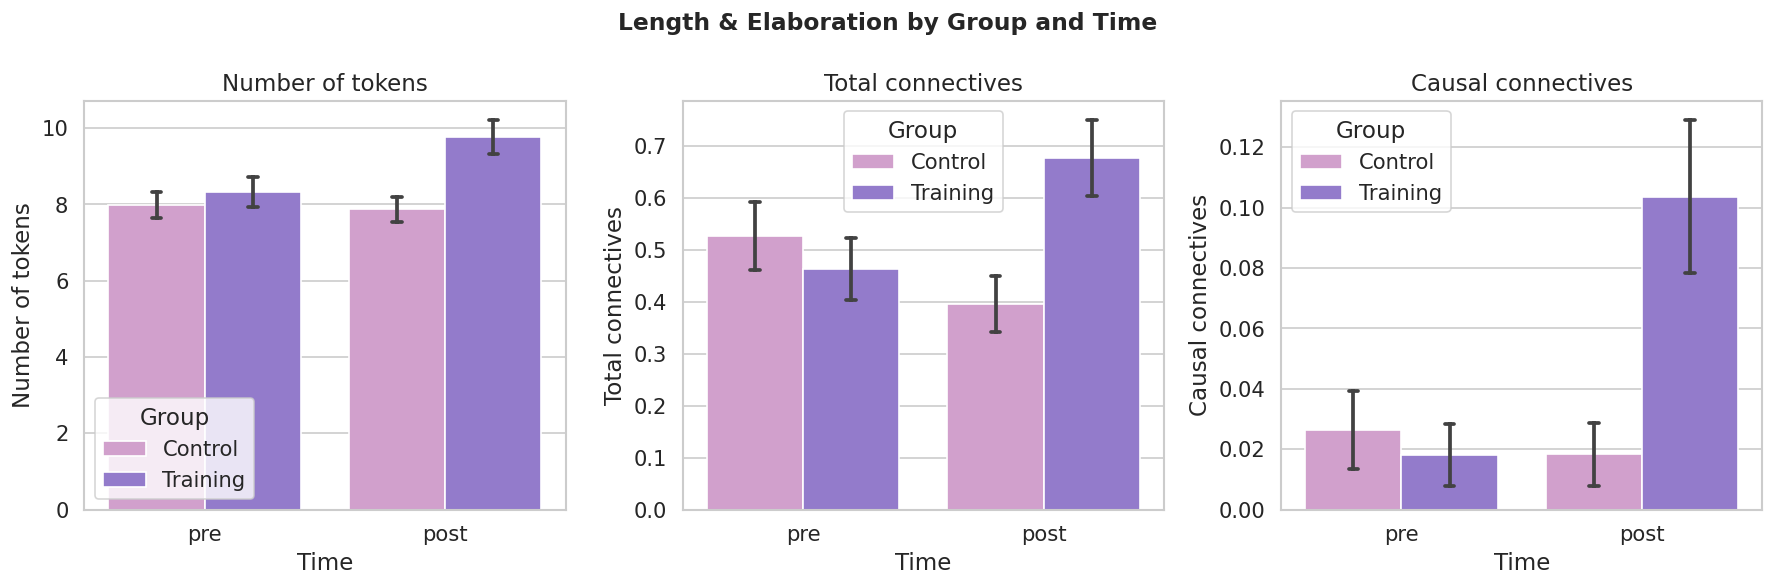

n_tokens               pre   G0=7.99 G1=8.33  U=12506 p=0.893
n_tokens               post  G0=7.87 G1=9.77  U=10936 p=0.003
n_connectives          pre   G0=0.53 G1=0.46  U=13116 p=0.471
n_connectives          post  G0=0.40 G1=0.68  U=11382 p=0.005
n_causal               pre   G0=0.03 G1=0.02  U=12720 p=0.619
n_causal               post  G0=0.02 G1=0.10  U=12380 p=0.002


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Length & Elaboration by Group and Time', fontsize=14, fontweight='bold')

for ax, (col, ylabel) in zip(axes, [
    ('n_tokens',      'Number of tokens'),
    ('n_connectives', 'Total connectives'),
    ('n_causal',      'Causal connectives'),
]):
    sns.barplot(
        data=feat_df, x='time', y=col, hue='group_label',
        palette=[COLORS[0], COLORS[1]],
        order=TIME_ORD, errorbar='se', capsize=.08, ax=ax,
    )
    ax.set_title(ylabel)
    ax.set_xlabel('Time')
    ax.set_ylabel(ylabel)
    ax.legend(title='Group')

plt.tight_layout()
plt.savefig('fig_length_connectives.pdf', bbox_inches='tight')
plt.show()

# Quick Mann-Whitney test: G0 vs G1 at post
for col in ('n_tokens', 'n_connectives', 'n_causal'):
    for t in ('pre', 'post'):
        g0 = feat_df[(feat_df['group']==0) & (feat_df['time']==t)][col].dropna()
        g1 = feat_df[(feat_df['group']==1) & (feat_df['time']==t)][col].dropna()
        u, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        print(f'{col:<22} {t:4s}  G0={g0.mean():.2f} G1={g1.mean():.2f}  U={u:.0f} p={p:.3f}')

## Plot 2 – TTR (Lexical Variability)

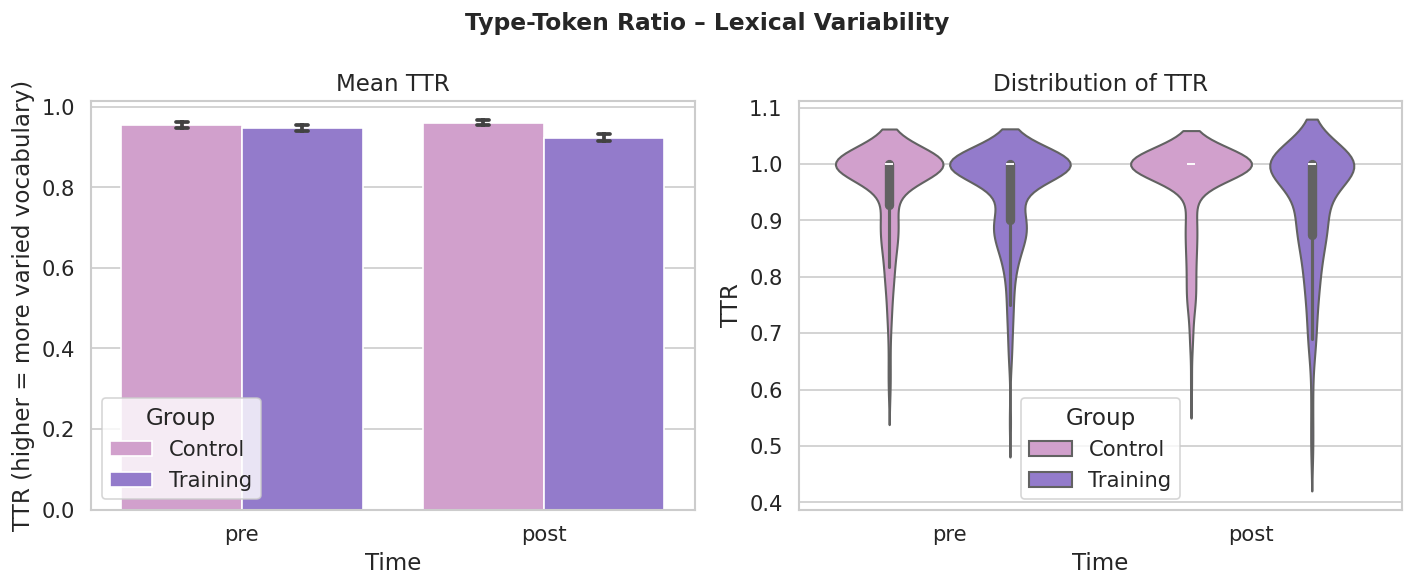

TTR pre   G0=0.955 G1=0.947  U=13433 p=0.226
TTR post  G0=0.961 G1=0.924  U=16271 p=0.000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Type-Token Ratio – Lexical Variability', fontsize=14, fontweight='bold')

# Barplot mean ± SE
sns.barplot(
    data=feat_df, x='time', y='ttr', hue='group_label',
    palette=[COLORS[0], COLORS[1]],
    order=TIME_ORD, errorbar='se', capsize=.08, ax=axes[0],
)
axes[0].set_title('Mean TTR')
axes[0].set_ylabel('TTR (higher = more varied vocabulary)')
axes[0].set_xlabel('Time')
axes[0].legend(title='Group')

# Violin to show distribution
sns.violinplot(
    data=feat_df, x='time', y='ttr', hue='group_label',
    palette=[COLORS[0], COLORS[1]],
    order=TIME_ORD, split=False, ax=axes[1],
)
axes[1].set_title('Distribution of TTR')
axes[1].set_ylabel('TTR')
axes[1].set_xlabel('Time')
axes[1].legend(title='Group')

plt.tight_layout()
plt.savefig('fig_ttr.pdf', bbox_inches='tight')
plt.show()

for t in ('pre', 'post'):
    g0 = feat_df[(feat_df['group']==0) & (feat_df['time']==t)]['ttr'].dropna()
    g1 = feat_df[(feat_df['group']==1) & (feat_df['time']==t)]['ttr'].dropna()
    u, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    print(f'TTR {t:4s}  G0={g0.mean():.3f} G1={g1.mean():.3f}  U={u:.0f} p={p:.3f}')

## Plot 3 – VAD (Valence · Arousal · Dominance)

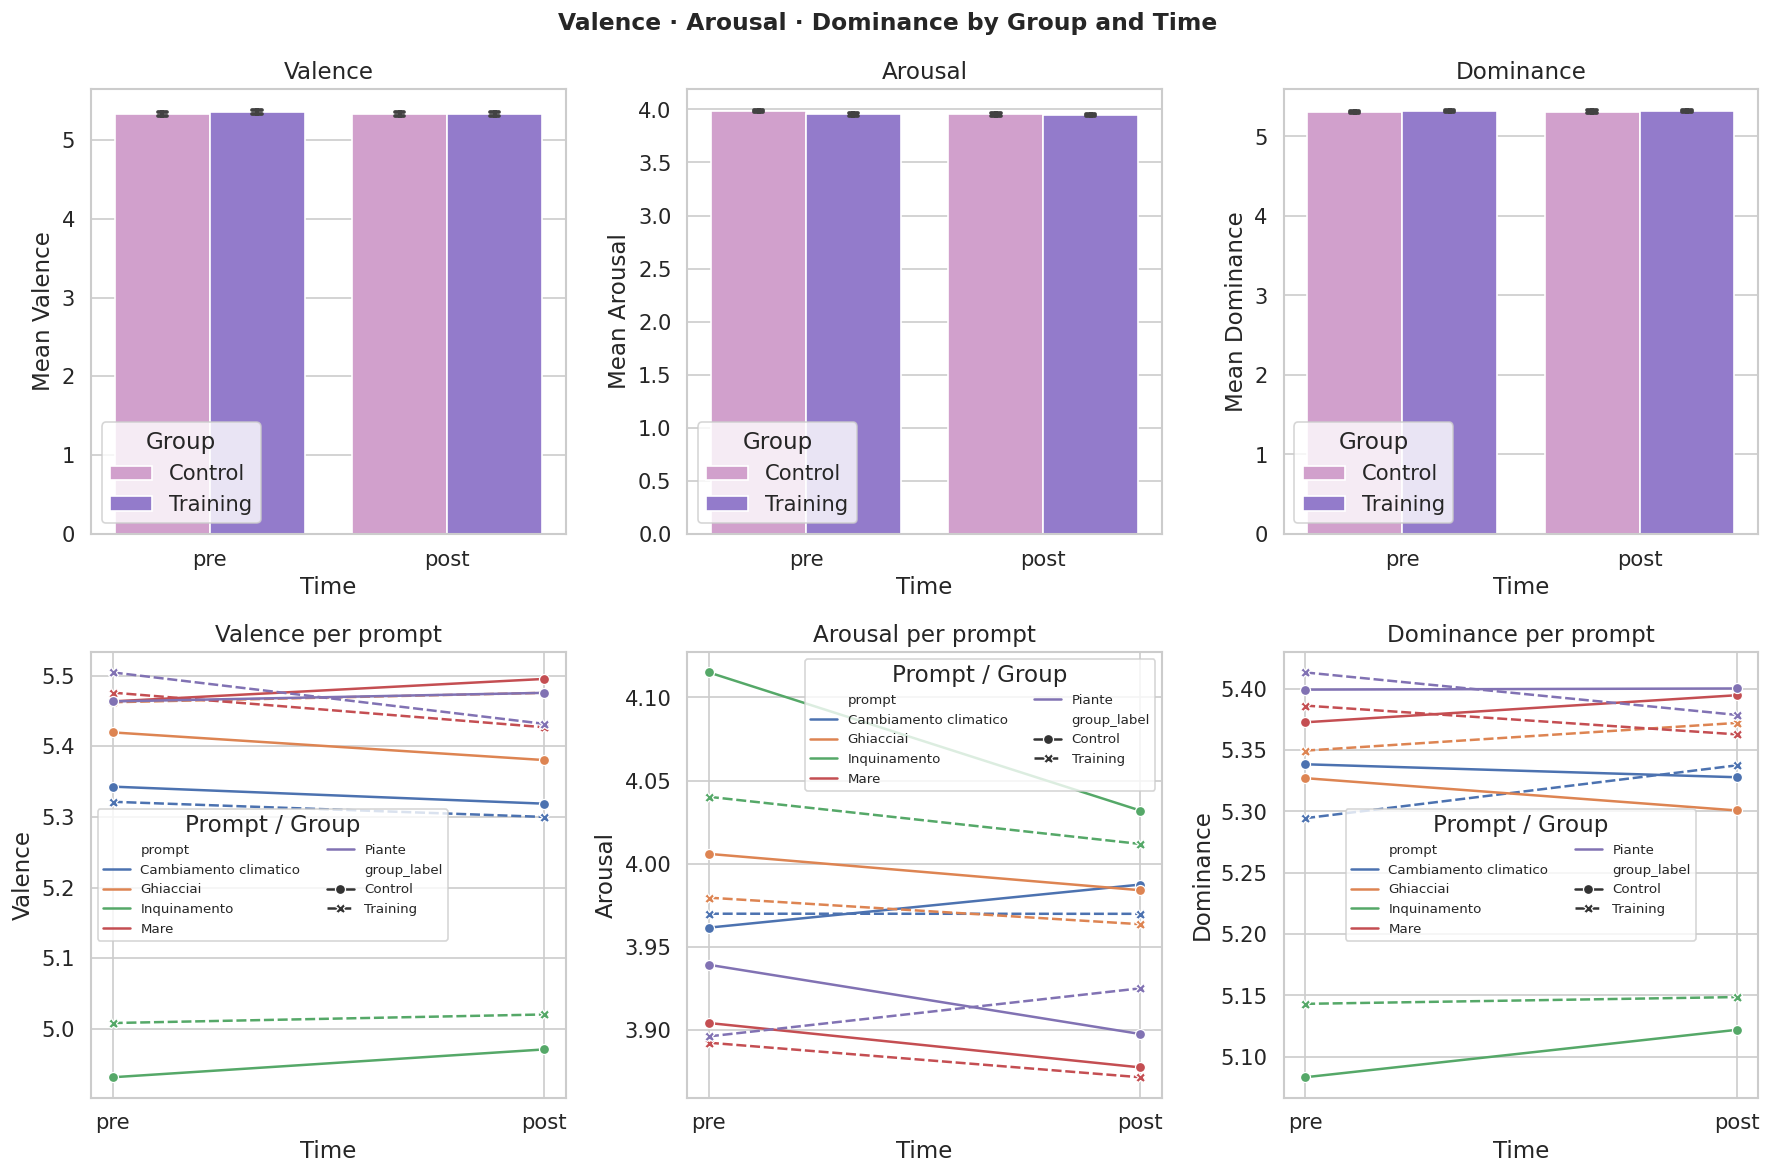

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Valence · Arousal · Dominance by Group and Time', fontsize=14, fontweight='bold')

dims = [('valence','Valence'), ('arousal','Arousal'), ('dominance','Dominance')]

for col_idx, (col, label) in enumerate(dims):
    pdata = feat_df.dropna(subset=[col])

    # Row 0: barplot
    ax = axes[0, col_idx]
    sns.barplot(
        data=pdata, x='time', y=col, hue='group_label',
        palette=[COLORS[0], COLORS[1]],
        order=TIME_ORD, errorbar='se', capsize=.08, ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Mean {label}')
    ax.legend(title='Group')

    # Row 1: per item (heatmap-style lineplot)
    ax2 = axes[1, col_idx]
    item_agg = (
        pdata.groupby(['group_label', 'time', 'prompt'])[col]
        .mean().reset_index()
    )
    sns.lineplot(
        data=item_agg, x='time', y=col,
        hue='prompt', style='group_label',
        markers=True, dashes=True, ax=ax2,
    )
    ax2.set_title(f'{label} per prompt')
    ax2.set_xlabel('Time')
    ax2.set_ylabel(label)
    ax2.legend(fontsize=8, title='Prompt / Group', ncol=2)

plt.tight_layout()
plt.savefig('fig_vad.pdf', bbox_inches='tight')
plt.show()

## Plot 4 – Most Frequent Content Terms

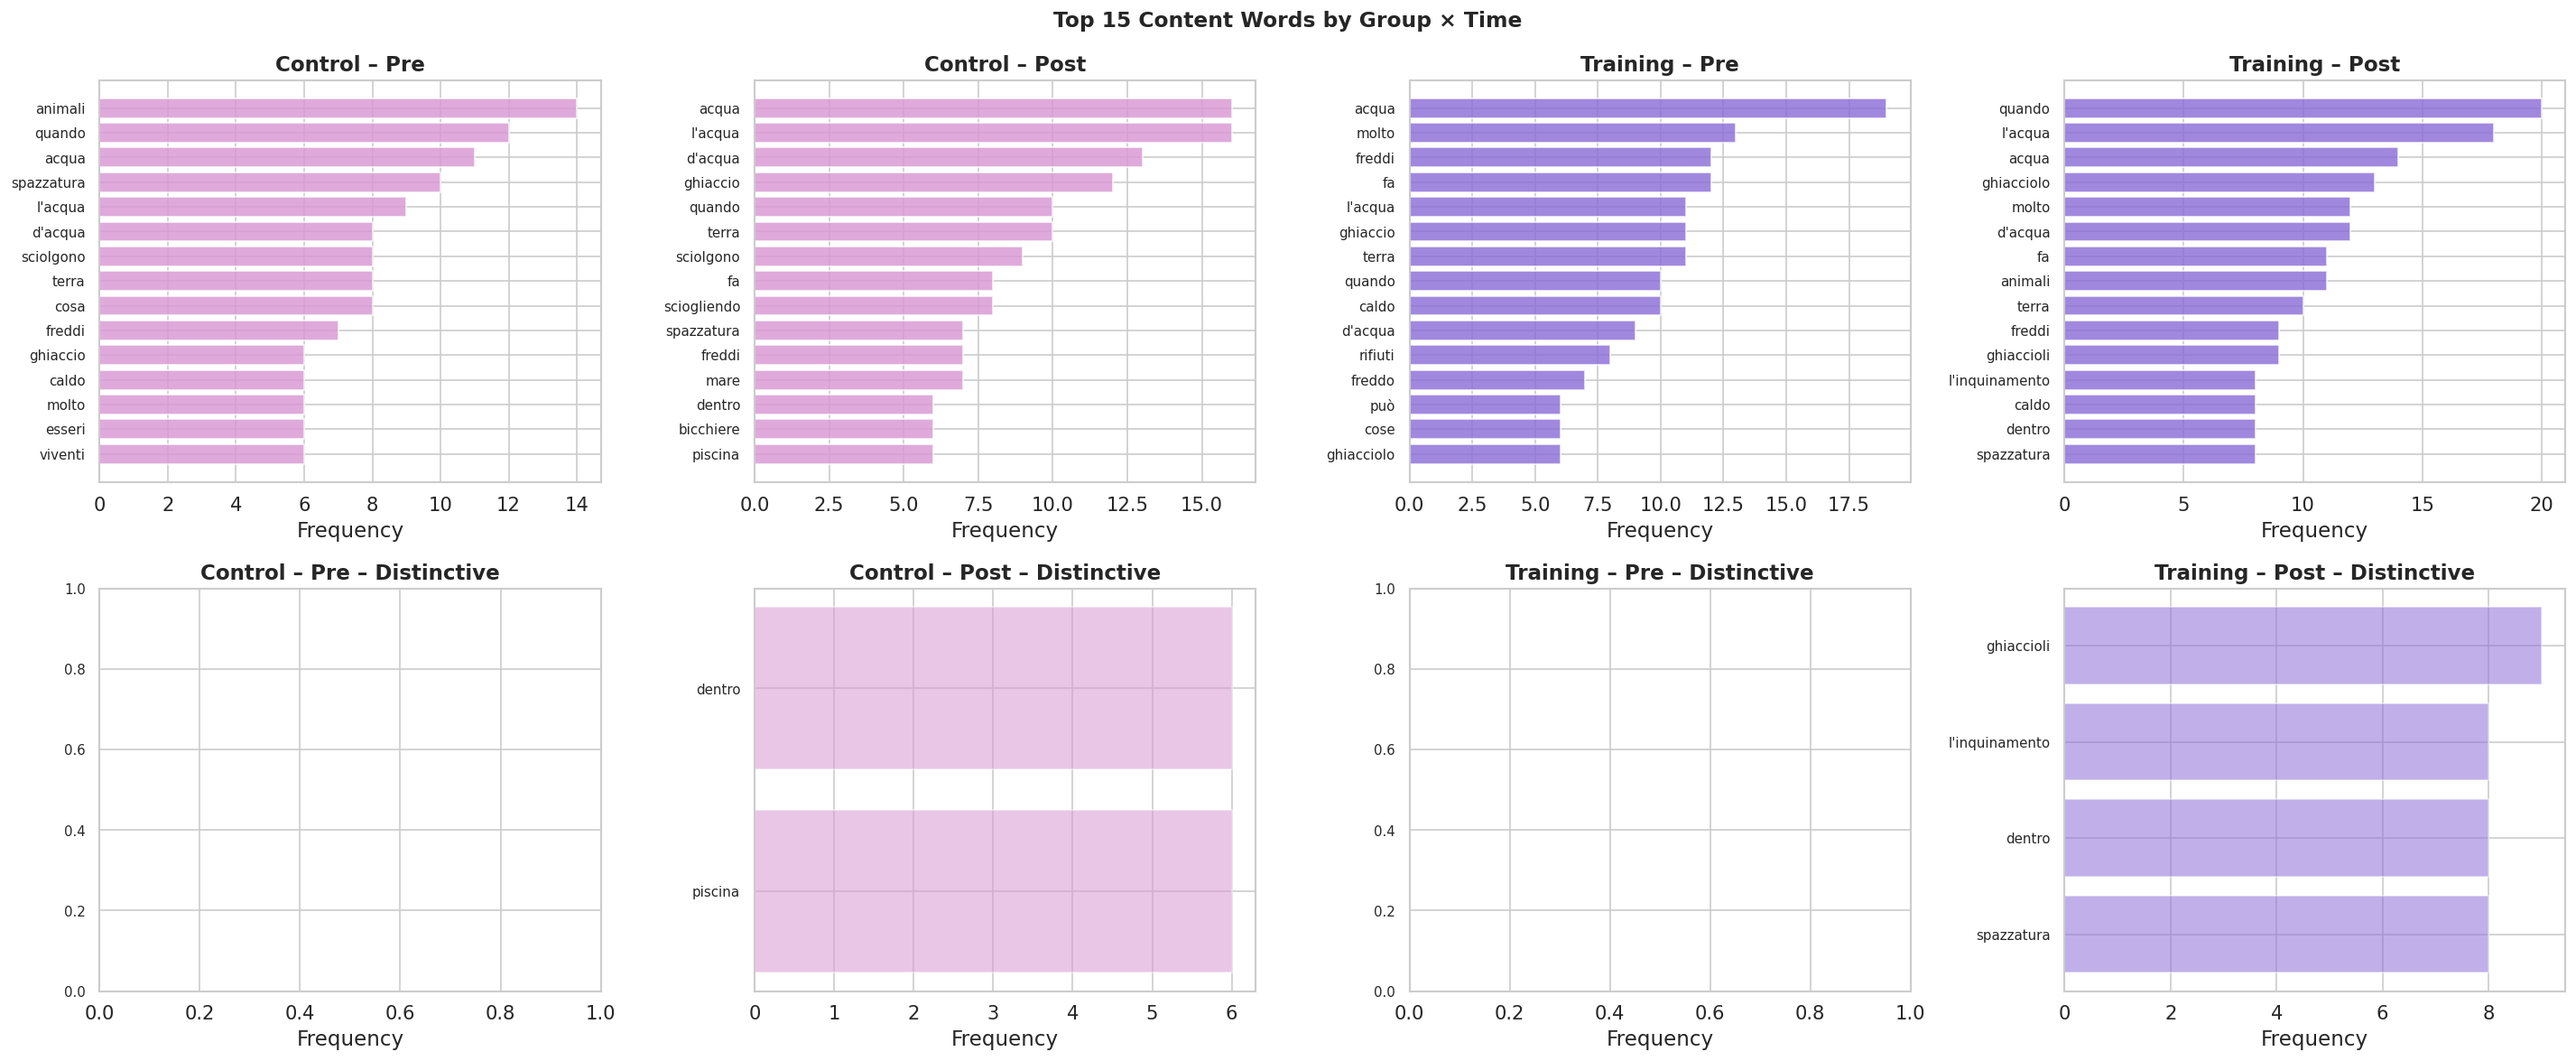

In [9]:
def top_content(subset_df, n=15):
    tokens = []
    for row in subset_df['content_tokens']:
        tokens.extend(row if isinstance(row, list) else [])
    return Counter(tokens).most_common(n)

conditions = [(0,'pre'),(0,'post'),(1,'pre'),(1,'post')]
titles     = ['Control – Pre','Control – Post','Training – Pre','Training – Post']

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('Top 15 Content Words by Group × Time', fontsize=14, fontweight='bold')

for col_idx, ((g, t), title) in enumerate(zip(conditions, titles)):
    sub  = feat_df[(feat_df['group']==g) & (feat_df['time']==t)]
    top  = top_content(sub, n=15)
    if not top:
        continue
    words, counts = zip(*top)

    # Row 0: overall top words
    ax = axes[0, col_idx]
    ax.barh(list(words)[::-1], list(counts)[::-1], color=COLORS[g], alpha=0.82, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

    # Row 1: words distinctive vs other time point
    other_t  = 'post' if t == 'pre' else 'pre'
    other_w  = {w for w, _ in top_content(feat_df[(feat_df['group']==g)&(feat_df['time']==other_t)], 50)}
    dist_top = [(w, c) for w, c in top if w not in other_w][:12]
    ax2 = axes[1, col_idx]
    if dist_top:
        dw, dc = zip(*dist_top)
        ax2.barh(list(dw)[::-1], list(dc)[::-1], color=COLORS[g], alpha=0.55, edgecolor='white')
    ax2.set_title(f'{title} – Distinctive', fontweight='bold')
    ax2.set_xlabel('Frequency')
    ax2.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('fig_top_terms.pdf', bbox_inches='tight')
plt.show()

## (Optional) Plot 5 – Concreteness / Imageability

Requires an Italian concreteness norms file (CSV with columns `word` and `concreteness`).  
Suggested sources:
- **Montefinese et al. (2014)** – 1,121 Italian words with valence, arousal, dominance, imageability  
- **Vergallito et al. (2020)** – Italian emotional norms including concreteness  

Set `CONCRETENESS_FILE` below to the path of your CSV, or leave `None` to skip.

In [10]:
CONCRETENESS_FILE = "/home/agnese.lombardi/progetto/metacom_green/megahr.it.csv"  

if CONCRETENESS_FILE and Path(CONCRETENESS_FILE).exists():
    conc_df = pd.read_csv(CONCRETENESS_FILE)
    # Normalise column names – adjust if yours differ
    conc_df.columns = [c.lower().strip() for c in conc_df.columns]
    conc_map = dict(zip(conc_df['words'].str.lower(), conc_df['concreteness']))

    def mean_concreteness(text):
        tokens = re.findall(r"[\w']+", text.lower())
        scores = [conc_map[t] for t in tokens if t in conc_map]
        return float(np.mean(scores)) if scores else np.nan

    feat_df['concreteness'] = feat_df['text'].apply(mean_concreteness)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(
        data=feat_df.dropna(subset=['concreteness']),
        x='time', y='concreteness', hue='group_label',
        palette=[COLORS[0], COLORS[1]],
        order=TIME_ORD, errorbar='se', capsize=.08, ax=ax,
    )
    ax.set_title('Mean Concreteness/Imageability by Group × Time', fontweight='bold')
    ax.set_ylabel('Mean concreteness (higher = more concrete)')
    ax.set_xlabel('Time')
    ax.legend(title='Group')
    plt.tight_layout()
    plt.savefig('fig_concreteness.pdf', bbox_inches='tight')
    plt.show()
else:
    print('⚠  Concreteness file not provided – skipping Plot 5.')
    print('   Set CONCRETENESS_FILE to a CSV with columns [word, concreteness].')

⚠  Concreteness file not provided – skipping Plot 5.
   Set CONCRETENESS_FILE to a CSV with columns [word, concreteness].


## Embeddings – Distance from Prompts

Using `paraphrase-multilingual-MiniLM-L12-v2` (cached locally).  
We compute the **cosine distance** between each answer and its corresponding topic prompt.  
Higher distance = the answer drifts further from the prompt topic.

Prompts: *Cambiamento climatico · Inquinamento · Ghiacciai · Mare · Piante*

In [11]:
# ── Load model (already cached) ───────────────────────────────────────────────
model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

# Encode the 5 prompts
prompt_texts = [PROMPTS[i] for i in range(1, 6)]
prompt_emb   = model.encode(prompt_texts, normalize_embeddings=True)

# Encode all answers
answer_texts = feat_df['text'].tolist()
answer_emb   = model.encode(answer_texts, normalize_embeddings=True, show_progress_bar=True)

print(f'Prompt embeddings:  {prompt_emb.shape}')
print(f'Answer embeddings:  {answer_emb.shape}')

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Prompt embeddings:  (5, 384)
Answer embeddings:  (646, 384)


In [12]:
# ── Cosine similarity / distance to the matching prompt ───────────────────────
sims, dists = [], []
for i, item in enumerate(feat_df['item']):
    prompt_vec  = prompt_emb[item - 1].reshape(1, -1)
    answer_vec  = answer_emb[i].reshape(1, -1)
    sim = float(cosine_similarity(answer_vec, prompt_vec)[0, 0])
    sims.append(sim)
    dists.append(1.0 - sim)

feat_df['cos_sim']  = sims
feat_df['cos_dist'] = dists

print('Mean cosine distance from prompt by group × time:')
feat_df.groupby(['group', 'time'])['cos_dist'].mean().round(4).to_frame()

Mean cosine distance from prompt by group × time:


cos_dist
group time          
0     pre     0.6530
      post    0.6502
1     pre     0.6640
      post    0.6759

## Plot 6 – Distance from Prompts (Overall + Per Item)

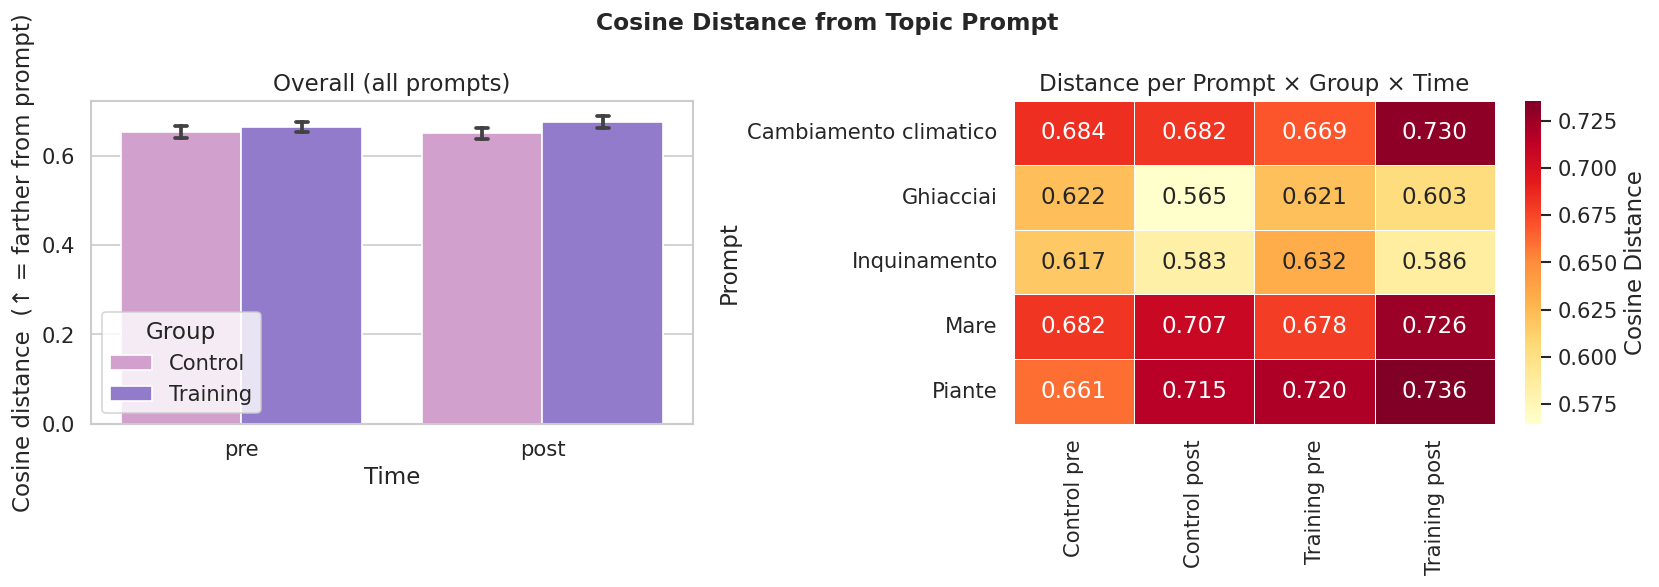

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cosine Distance from Topic Prompt', fontsize=14, fontweight='bold')

# Panel A – overall
sns.barplot(
    data=feat_df, x='time', y='cos_dist', hue='group_label',
    palette=[COLORS[0], COLORS[1]],
    order=TIME_ORD, errorbar='se', capsize=.08, ax=axes[0],
)
axes[0].set_title('Overall (all prompts)')
axes[0].set_ylabel('Cosine distance  (↑ = farther from prompt)')
axes[0].set_xlabel('Time')
axes[0].legend(title='Group')

# Panel B – per prompt heatmap
heat = (
    feat_df.groupby(['prompt', 'group', 'time'])['cos_dist']
    .mean()
    .reset_index()
    .pivot(index='prompt', columns=['group', 'time'], values='cos_dist')
)
heat.columns = [f'{LABELS[g]} {t}' for g, t in heat.columns]
heat = heat[[f'{LABELS[0]} pre', f'{LABELS[0]} post', f'{LABELS[1]} pre', f'{LABELS[1]} post']]

sns.heatmap(
    heat, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=.5, ax=axes[1],
    cbar_kws={'label': 'Cosine Distance'},
)
axes[1].set_title('Distance per Prompt × Group × Time')
axes[1].set_ylabel('Prompt')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('fig_embedding_distance.pdf', bbox_inches='tight')
plt.show()

## Plot 7 – Delta Distance Pre → Post (Broadening vs Narrowing)

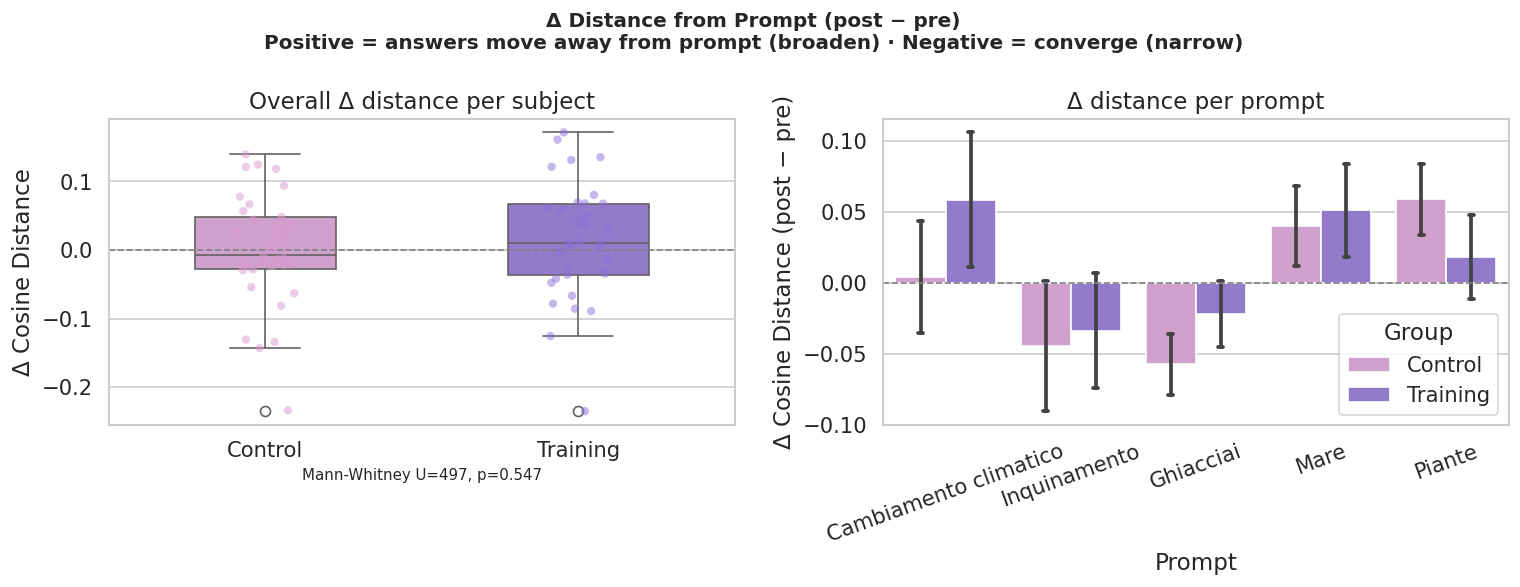

Group means Δ distance:
               mean     std  median
group_label                        
Control     -0.0002  0.0835 -0.0070
Training     0.0133  0.0864  0.0098


In [14]:
# Per-subject mean distance, then delta = post - pre
subj_dist = (
    feat_df.groupby(['subject', 'group', 'group_label', 'time'])['cos_dist']
    .mean().reset_index()
    .pivot(index=['subject','group','group_label'], columns='time', values='cos_dist')
    .reset_index()
)
subj_dist['delta'] = subj_dist['post'] - subj_dist['pre']

# Per-subject × per-prompt delta
prompt_dist = (
    feat_df.groupby(['subject','group','group_label','prompt','time'])['cos_dist']
    .mean().reset_index()
    .pivot(index=['subject','group','group_label','prompt'], columns='time', values='cos_dist')
    .reset_index()
)
prompt_dist['delta'] = prompt_dist['post'] - prompt_dist['pre']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Δ Distance from Prompt (post − pre)\n'
    'Positive = answers move away from prompt (broaden) · Negative = converge (narrow)',
    fontsize=12, fontweight='bold',
)

# Panel A – boxplot per group
sns.boxplot(
    data=subj_dist, x='group_label', y='delta',
    palette=[COLORS[0], COLORS[1]], width=.45,
    order=[LABELS[0], LABELS[1]], ax=axes[0],
)
sns.stripplot(
    data=subj_dist, x='group_label', y='delta',
    palette=[COLORS[0], COLORS[1]], alpha=.5, jitter=True, size=5,
    order=[LABELS[0], LABELS[1]], ax=axes[0],
)
axes[0].axhline(0, color='gray', lw=1, ls='--')
axes[0].set_title('Overall Δ distance per subject')
axes[0].set_ylabel('Δ Cosine Distance')
axes[0].set_xlabel('')

u, p = stats.mannwhitneyu(
    subj_dist[subj_dist['group']==0]['delta'].dropna(),
    subj_dist[subj_dist['group']==1]['delta'].dropna(),
    alternative='two-sided',
)
axes[0].set_xlabel(f'Mann-Whitney U={u:.0f}, p={p:.3f}', fontsize=9)

# Panel B – per prompt
sns.barplot(
    data=prompt_dist, x='prompt', y='delta', hue='group_label',
    palette=[COLORS[0], COLORS[1]],
    order=list(PROMPTS.values()),
    errorbar='se', capsize=.08, ax=axes[1],
)
axes[1].axhline(0, color='gray', lw=1, ls='--')
axes[1].set_title('Δ distance per prompt')
axes[1].set_ylabel('Δ Cosine Distance (post − pre)')
axes[1].set_xlabel('Prompt')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Group')

plt.tight_layout()
plt.savefig('fig_embedding_shift.pdf', bbox_inches='tight')
plt.show()

print('Group means Δ distance:')
print(subj_dist.groupby('group_label')['delta'].agg(['mean','std','median']).round(4))

## Plot 8 – PCA Projection: Answers + Prompt Anchors

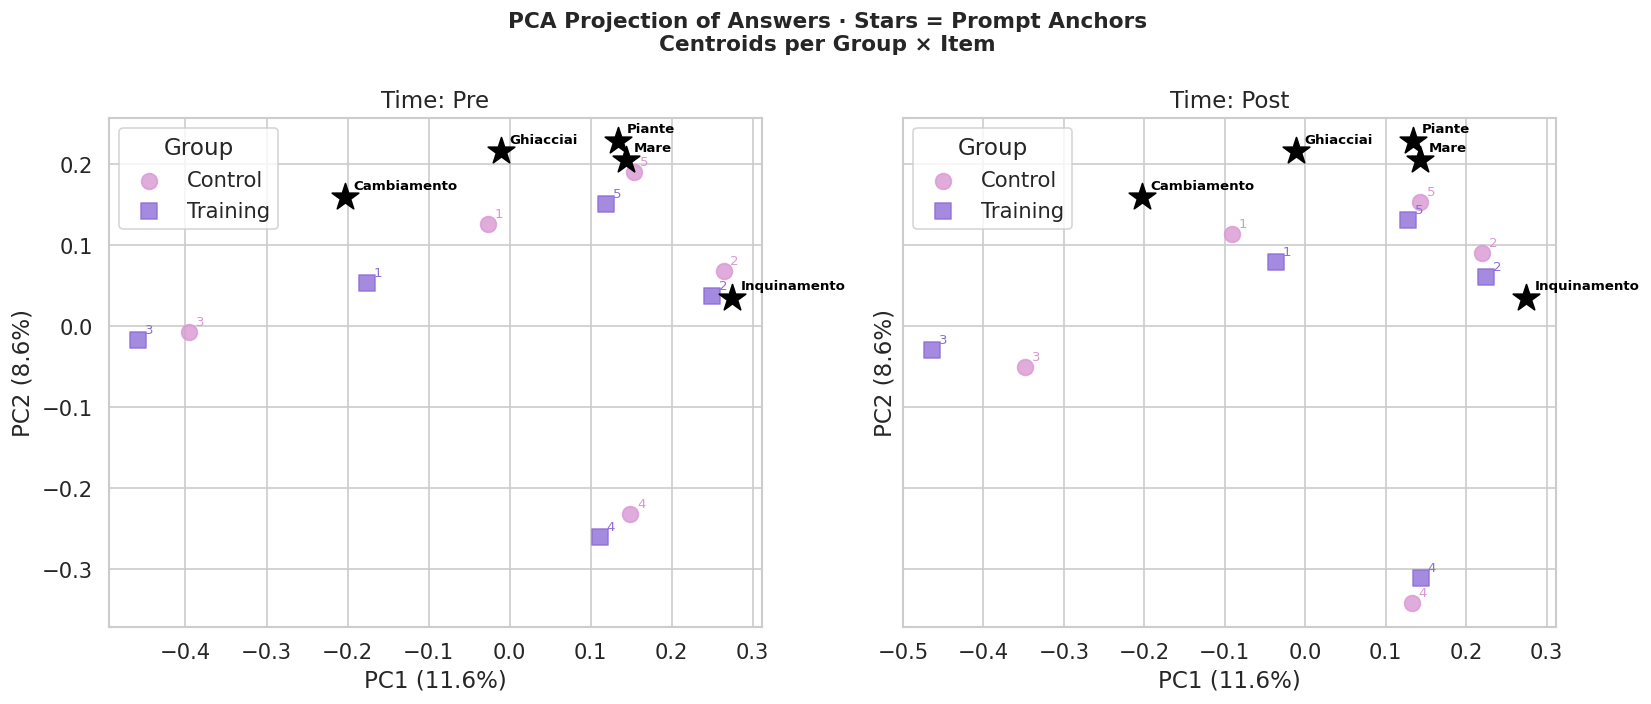

In [15]:
# PCA on all embeddings together (prompts as anchors)
all_emb  = np.vstack([prompt_emb, answer_emb])
pca      = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(all_emb)

prompt_coords = coords[:5]
feat_df['pc1'] = coords[5:, 0]
feat_df['pc2'] = coords[5:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle(
    'PCA Projection of Answers · Stars = Prompt Anchors\n'
    'Centroids per Group × Item',
    fontsize=13, fontweight='bold',
)

for ax, time in zip(axes, ['pre', 'post']):
    sub = feat_df[feat_df['time'] == time]
    legend_done = set()
    for g in (0, 1):
        gsub = sub[sub['group'] == g]
        for item in range(1, 6):
            isub = gsub[gsub['item'] == item]
            if isub.empty:
                continue
            cx, cy = isub['pc1'].mean(), isub['pc2'].mean()
            lbl = LABELS[g] if g not in legend_done else '_nolegend_'
            ax.scatter(cx, cy, color=COLORS[g], s=90, alpha=.8,
                       marker='o' if g == 0 else 's', label=lbl)
            legend_done.add(g)
            ax.annotate(str(item), (cx, cy),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=8, color=COLORS[g])

    for i, (px, py) in enumerate(prompt_coords):
        ax.scatter(px, py, color='black', marker='*', s=280, zorder=6)
        ax.annotate(
            PROMPTS[i + 1].split()[0], (px, py),
            textcoords='offset points', xytext=(5, 5),
            fontsize=8, color='black', fontweight='bold',
        )

    ax.set_title(f'Time: {time.capitalize()}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(title='Group', loc='best')

plt.tight_layout()
plt.savefig('fig_pca_projection.pdf', bbox_inches='tight')
plt.show()

## Summary Table – All Metrics by Group × Time

In [16]:
metrics_cols = ['n_tokens', 'ttr', 'conn_rate', 'causal_rate',
                'valence', 'arousal', 'dominance', 'cos_dist']

summary = (
    feat_df.groupby(['group_label', 'time'])[metrics_cols]
    .agg(['mean', 'std'])
    .round(3)
)
summary

n_tokens           ttr        conn_rate        causal_rate  \
                     mean    std   mean    std      mean    std        mean   
group_label time                                                              
Control     pre     7.987  4.186  0.955  0.085     0.048  0.069       0.003   
            post    7.872  4.204  0.961  0.082     0.037  0.061       0.002   
Training    pre     8.325  5.056  0.947  0.087     0.040  0.061       0.002   
            post    9.768  5.709  0.924  0.110     0.055  0.069       0.011   

                        valence        arousal        dominance         \
                    std    mean    std    mean    std      mean    std   
group_label time                                                         
Control     pre   0.018   5.329  0.357   3.984  0.160     5.307  0.208   
            post  0.012   5.328  0.337   3.955  0.164     5.309  0.211   
Training    pre   0.016   5.358  0.355   3.955  0.163     5.319  0.207   
            post  0.038   5.331  0.318   3.948  0.168     5.320  0.187   

                 cos_dist         
                     mean    std  
group_label time                  
Control     pre     0.653  0.156  
            post    0.650  0.149  
Training    pre     0.664  0.140  
            post    0.676  0.172